In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'xgboost', 'pyarrow', 'polars'])
import os, gc
import pickle
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import xgboost as xgb
import polars as pl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import optuna
from optuna.samplers import TPESampler

INPUT_DIR = '/kaggle/input/datasets/b22dckh072/file05/' 
TRAIN_PATH = os.path.join(INPUT_DIR, 'train_interactions.parquet')
META_PATH  = os.path.join(INPUT_DIR, 'filtered_metadata.parquet')
CAND_PATH  = os.path.join(INPUT_DIR, 'candidates_phase2.parquet')
FEAT_OUT   = os.path.join(INPUT_DIR, 'features.parquet')
TEST_PATH  = os.path.join(INPUT_DIR, 'test_interactions.parquet')

FEATURES = [
    'user_total_actions', 
    'item_total_sales', 
    'price', 
    'average_rating',
    'rating_number',
    'user_avg_rating_given',
    'item_actual_avg_rating',  
    'item_verified_ratio',      # Tỷ lệ mua thật
    'item_log_helpful_votes',   # Điểm hữu ích (Log)
    'store_popularity',                    # Tên thương hiệu (Categorical)
    'main_category',       #  Loại trang phục (Categorical)
    'sasrec_score', 
    'lightgcn_score'
]

Đang nạp file đặc trưng bằng Polars 
Đang chuyển qua Pandas và khóa từ điển Categorical...
Đang sắp xếp dữ liệu theo User ID (Yêu cầu bắt buộc của XGBoost Ranker)...
Đã lưu từ điển tại /kaggle/working/category_dict.pkl
Đang chuyển đổi cấu trúc dữ liệu cho XGBoost...


[I 2026-05-16 07:23:04,272] A new study created in memory with name: no-name-c730dd2e-96c8-4ee9-8f16-8a9a45a111ea


Bắt đầu chiến dịch dò tìm siêu tham số với Optuna (15 Trials)...


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-05-16 07:40:26,687] Trial 0 finished with value: 0.9148965620030255 and parameters: {'max_depth': 7, 'learning_rate': 0.2536999076681772, 'subsample': 0.892797576724562, 'colsample_bytree': 0.8394633936788146, 'min_child_weight': 9}. Best is trial 0 with value: 0.9148965620030255.
[I 2026-05-16 08:30:09,276] Trial 1 finished with value: 0.9113945753544693 and parameters: {'max_depth': 6, 'learning_rate': 0.012184186502221764, 'subsample': 0.9464704583099741, 'colsample_bytree': 0.8404460046972835, 'min_child_weight': 23}. Best is trial 0 with value: 0.9148965620030255.
[I 2026-05-16 09:05:29,030] Trial 2 finished with value: 0.9149524292665138 and parameters: {'max_depth': 5, 'learning_rate': 0.2708160864249968, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'min_child_weight': 9}. Best is trial 2 with value: 0.9149524292665138.
[I 2026-05-16 09:55:24,293] Trial 3 finished with value: 0.9138608909309367 and parameters: {'max_depth': 6, 'learning_rate':

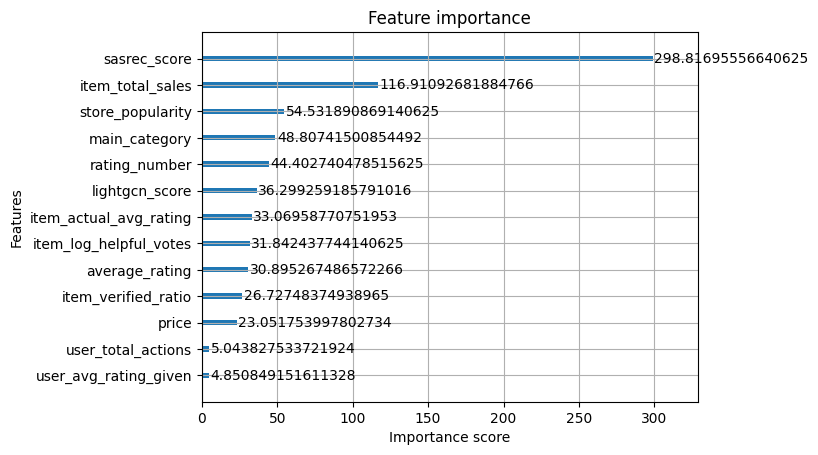

/tmp/ipykernel_23/845306750.py:111: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


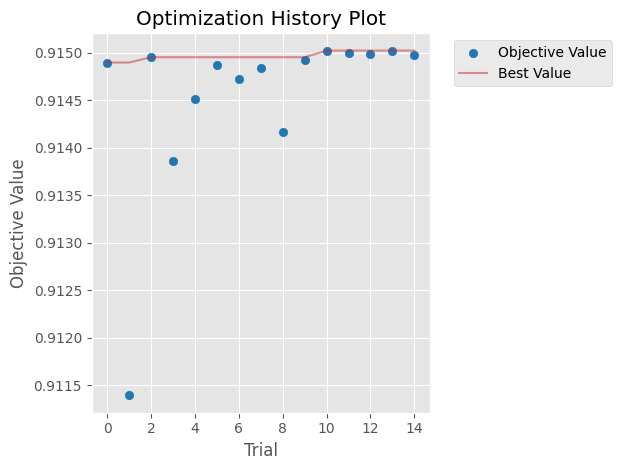

9526

In [2]:
import os
import gc
import pickle
import polars as pl
import pandas as pd
import xgboost as xgb
import optuna
from optuna.samplers import TPESampler
import matplotlib.pyplot as plt

print("Đang nạp file đặc trưng bằng Polars ")
df_train = pl.read_parquet(FEAT_OUT) 
X_train = df_train.select(FEATURES + ['mapped_user_id'])
y_train = df_train.select(['label'])

print("Đang chuyển qua Pandas và khóa từ điển Categorical...")
X_train_pd = X_train.to_pandas()
y_train_pd = y_train.to_pandas()

print("Đang sắp xếp dữ liệu theo User ID (Yêu cầu bắt buộc của XGBoost Ranker)...")
X_train_pd['label'] = y_train_pd['label']
X_train_pd = X_train_pd.sort_values('mapped_user_id').reset_index(drop=True)

y_train_pd = X_train_pd[['label']]
qid_train = X_train_pd['mapped_user_id']
X_train_pd = X_train_pd.drop(columns=['mapped_user_id', 'label'])
X_train_pd['main_category'] = X_train_pd['main_category'].astype(str).astype('category')
with open('/kaggle/working/category_dict.pkl', 'wb') as f:
    pickle.dump({
        'main_category': X_train_pd['main_category'].cat.categories
    }, f)
print("Đã lưu từ điển tại /kaggle/working/category_dict.pkl")

print("Đang chuyển đổi cấu trúc dữ liệu cho XGBoost...")
dtrain = xgb.DMatrix(X_train_pd, label=y_train_pd, qid=qid_train, enable_categorical=True)

del X_train_pd, y_train_pd, df_train, X_train, y_train, qid_train
gc.collect()

constraints = {
    'sasrec_score': 1,    
    'lightgcn_score': 1   
}

def objective(trial):
    param = {
        'tree_method': 'hist',       
        'device': 'cuda',            
        'objective': 'rank:pairwise', 
        'eval_metric': 'ndcg@10', 
        
        # Mở rộng không gian tìm kiếm
        'max_depth': trial.suggest_int('max_depth', 5, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 30),
        
        'monotone_constraints': constraints
    }

    cv_results = xgb.cv(
        param,
        dtrain,
        num_boost_round=800, 
        nfold=3,             
        early_stopping_rounds=50, 
        metrics='ndcg@10',
        seed=42,
        verbose_eval=False
    )
    best_ndcg = cv_results['test-ndcg@10-mean'].max()
    
    trial.set_user_attr("best_num_trees", cv_results.shape[0])
    
    return best_ndcg

print("Bắt đầu chiến dịch dò tìm siêu tham số với Optuna (15 Trials)...")
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
# Đồng bộ số n_trials với thông báo in ra
study.optimize(objective, n_trials=15, show_progress_bar=True) 

print("=========================================")
print(f"Điểm NDCG tốt nhất tìm được: {study.best_value:.4f}")
print("Cấu hình siêu tham số tốt nhất:")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")
print("=========================================")

print("\nTiến hành huấn luyện mô hình...")
best_params = study.best_params
best_params['tree_method'] = 'hist'
best_params['device'] = 'cuda'
best_params['objective'] = 'rank:pairwise'
best_params['eval_metric'] = 'ndcg@10'
best_params['monotone_constraints'] = constraints
best_trees = study.best_trial.user_attrs["best_num_trees"]

model = xgb.train(best_params, dtrain, num_boost_round=best_trees)

# Lưu mô hình
model_path = '/kaggle/working/xgboost_ranking_model.json'
model.save_model(model_path)
print(f"Huấn luyện hoàn tất! Đã lưu mô hình tinh anh tại: {model_path}")

xgb.plot_importance(model, importance_type='gain')
plt.show()

# Trực quan hóa quá trình tìm kiếm của Optuna
try:
    optuna.visualization.matplotlib.plot_optimization_history(study)
    plt.show()
except:
    pass

del dtrain
gc.collect()

In [3]:
import polars as pl

# Trỏ đến file features.parquet mà File 06 dùng để huấn luyện
FEAT_OUT = '/kaggle/input/datasets/b22dckh072/file05/features.parquet' 

print("Đang quét X-quang tập dữ liệu Huấn luyện (Train Data)...")
df_train = pl.read_parquet(FEAT_OUT)

# Thống kê điểm trung bình của SASRec và LightGCN chia theo Nhãn (Mua thật vs Không mua)
stats = df_train.group_by('label').agg([
    pl.len().alias('Tổng số dòng'),
    pl.col('sasrec_score').mean().alias('Điểm SASRec (TB)'),
    pl.col('lightgcn_score').mean().alias('Điểm LightGCN (TB)'),
    (pl.col('sasrec_score') == 0).sum().alias('Số món bị 0 điểm SASRec'),
]).sort('label', descending=True)

print(stats)

Đang quét X-quang tập dữ liệu Huấn luyện (Train Data)...
shape: (2, 5)
┌───────┬──────────────┬──────────────────┬────────────────────┬─────────────────────────┐
│ label ┆ Tổng số dòng ┆ Điểm SASRec (TB) ┆ Điểm LightGCN (TB) ┆ Số món bị 0 điểm SASRec │
│ ---   ┆ ---          ┆ ---              ┆ ---                ┆ ---                     │
│ i8    ┆ u32          ┆ f32              ┆ f32                ┆ u32                     │
╞═══════╪══════════════╪══════════════════╪════════════════════╪═════════════════════════╡
│ 1     ┆ 84383        ┆ 104.119644       ┆ 114.846832         ┆ 22923                   │
│ 0     ┆ 25766550     ┆ 89.874855        ┆ 88.595009          ┆ 6814256                 │
└───────┴──────────────┴──────────────────┴────────────────────┴─────────────────────────┘


In [4]:
import polars as pl

# Đọc file dữ liệu đã tạo
df_train = pl.read_parquet(FEAT_OUT)

# Chỉ lọc ra những món khách hàng thực sự mua (Nhãn 1)
positives = df_train.filter(pl.col('label') == 1)

print("Tổng số món khách mua thật (Nhãn 1):", positives.height)
print("Số món do SASRec đoán trúng (Score > 0):", positives.filter(pl.col('sasrec_score') > 0.0).height)
print("Số món do LightGCN đoán trúng (Score > 0):", positives.filter(pl.col('lightgcn_score') > 0.0).height)

Tổng số món khách mua thật (Nhãn 1): 84383
Số món do SASRec đoán trúng (Score > 0): 61460
Số món do LightGCN đoán trúng (Score > 0): 70716
